In [115]:
import pandas as pd
import seaborn as sns
import numpy as np
from numpy import gradient
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import r2_score
from scipy.ndimage.filters import gaussian_filter1d
import math
from scipy import stats
from pygam import LinearGAM, s

def calc_derivatives(x,y):
    """ Calculate the derivative of the fitted function"""
    """
    x: list of points
    y: list of points
    """
    dx = np.diff(x)
    dy = np.diff(y)
    derivative = dy / dx
    return derivative

warnings.filterwarnings( 'ignore' )

pd.options.display.max_columns = None
pd.options.display.max_rows = None

species_color = {'Marmoset': "orange",'Human': "green",'Rhesus': "blue",'Chimpanzee': "red", 'Capuchin': "brown","Gorilla": "pink"}

adult_sizes_df = pd.read_excel("/Users/rb4174/Library/CloudStorage/OneDrive-PrincetonUniversity/Projects/brain_dev_primates/data/adult_primates_brain_volumes.xlsx",
                               sheet_name="from_ref") # "from_ref", from_my_data
adult_sizes_df = adult_sizes_df.replace("chimpanzee", "Chimpanzee")
adult_sizes_df = adult_sizes_df.replace("human", "Human")
adult_sizes_df = adult_sizes_df.replace("marmoset", "Marmoset")
adult_sizes_df = adult_sizes_df.replace("rhesus", "Rhesus")

adult_sizes = {}
for specie in adult_sizes_df["species"].unique():
    adult_sizes[specie] = np.mean(adult_sizes_df[(adult_sizes_df.species == specie)]["total_cm3"])


PYTHON_PATH = "/Users/rb4174/Library/CloudStorage/OneDrive-PrincetonUniversity/Projects/brain_dev_primates/altricial_brain_vocal_learning"


In [116]:
def norm_distances_from_peak(x_values,each_derivative,gestation_avg,gestation_sd):
    """Calculate the normalized y distances from the peak of the derivative at birth."""
    y_distance_from_peak_norm = []
    max_derivative = np.max(each_derivative)
    for x,y in zip(x_values,each_derivative):
        if x > gestation_avg - gestation_sd and x < gestation_avg + gestation_sd:
            y_distance_from_peak_norm.append((max_derivative-y)/max_derivative)

    return y_distance_from_peak_norm
    

def X_distances_from_peak(x_values,each_derivative,gestation_avg,gestation_sd):
    """Calculate the x distances from the peak of the derivative at birth."""
    x_distance_from_peak = []
    x_of_max_derivative = x_values[np.argmax(each_derivative)]
    for x,y in zip(x_values,each_derivative):
        if x > gestation_avg - gestation_sd and x < gestation_avg + gestation_sd:
            x_distance_from_peak.append((x-x_of_max_derivative))

    return x_distance_from_peak

def volume_percents_at_birth(x_values,y_values,gestation_avg,gestation_sd,species):
    """Calculate the x distances from the peak of the derivative at birth."""
    percents_at_birth = []
    adult_size = adult_sizes[species]
    for x,y in zip(x_values,y_values):
        if x > gestation_avg - gestation_sd and x < gestation_avg + gestation_sd:
            percents_at_birth.append((y/adult_size)*100)

    return percents_at_birth

def create_derivatives_dataset(sensitivity_df,x_each_species,species_list,gestation_periods_plot,gestation_periods_sd):
    derivatives_dataset = {"Species":[],
        "derivatives":[],
        "derivatives_wiggliness":[],
        "derivatives_max":[],
        "norm_y_distance_from_peak_at_birth":[],
        "x_distance_from_peak_at_birth":[],
        "percent_growth_at_birth":[],
        "growth_curve_r2_score":[],
        "growth_curve_wiggliness":[]}
    
    sensitivity_df["derivative_wiggliness"] = [None]*len(sensitivity_df)
    sensitivity_df["x_distance_from_peak"] = [None]*len(sensitivity_df)

    for species in species_list:
        sensitivity_df_species = sensitivity_df[(sensitivity_df.Species == species)]
        all_derivatives = []
        all_derivatives_wiggliness = []
        all_derivatives_max = []
        all_derivatives_norm_distance_from_peak_at_birth = []
        all_percents_growth_at_birth = []
        all_derivatives_X_distance_from_peak_at_birth = []
        x_values = x_each_species[species]
        r2_original_fit = []
        wiggliness_original_fit = []
        for index, row in sensitivity_df_species.iterrows():
            y_values = row["values"]

            #each_derivative = calc_derivatives(x_values,y_values)
            each_derivative = gradient(y_values, x_values)
            each_derivative_wiggliness = np.sum(gradient(gradient(each_derivative, x_values), x_values)**2)
            each_derivative_max = np.max(each_derivative)
            each_derivative_norm_distance_from_peak_at_birth = norm_distances_from_peak(x_values,each_derivative,gestation_periods_plot[species],gestation_periods_sd[species])
            each_derivative_X_distance_from_peak_at_birth = X_distances_from_peak(x_values,each_derivative,gestation_periods_plot[species],gestation_periods_sd[species])
            each_curve_percent_at_birth = volume_percents_at_birth(x_values,y_values,gestation_periods_plot[species],gestation_periods_sd[species],species)


            all_percents_growth_at_birth.append(each_curve_percent_at_birth)
            all_derivatives.append(each_derivative)
            all_derivatives_wiggliness.append(each_derivative_wiggliness)
            all_derivatives_max.append(each_derivative_max)
            all_derivatives_norm_distance_from_peak_at_birth.append(each_derivative_norm_distance_from_peak_at_birth)
            all_derivatives_X_distance_from_peak_at_birth.append(each_derivative_X_distance_from_peak_at_birth)
            r2_original_fit.append(row["r2_score"])
            wiggliness_original_fit.append(row["wiggliness"])  

            sensitivity_df.loc[index,"derivative_wiggliness"] = each_derivative_wiggliness 
            sensitivity_df.loc[index,"x_distance_from_peak"] = np.average(each_derivative_X_distance_from_peak_at_birth)
         


        derivatives_dataset["Species"].append(species)
        derivatives_dataset["derivatives"].append(all_derivatives)
        derivatives_dataset["derivatives_wiggliness"].append(all_derivatives_wiggliness)
        derivatives_dataset["derivatives_max"].append(all_derivatives_max)
        derivatives_dataset["norm_y_distance_from_peak_at_birth"].append(all_derivatives_norm_distance_from_peak_at_birth)
        derivatives_dataset["x_distance_from_peak_at_birth"].append(all_derivatives_X_distance_from_peak_at_birth)
        derivatives_dataset["percent_growth_at_birth"].append(all_percents_growth_at_birth)
        derivatives_dataset["growth_curve_r2_score"].append(r2_original_fit)
        derivatives_dataset["growth_curve_wiggliness"].append(wiggliness_original_fit)

    derivatives_dataset = pd.DataFrame(derivatives_dataset)
    derivatives_dataset.head()

    return derivatives_dataset, sensitivity_df
    

# Opening and preparing datasets

In [3]:
df = pd.read_excel("{0}/data/brain_growth_complete.xlsx".format(PYTHON_PATH),index_col=False)

df.loc[len(df.index) + 1] = [0,0,'Human',"Contour condition",0,0,0]
df.loc[len(df.index) + 1] = [0,0,'Chimpanzee',"Contour condition",0,0,0] 
df.loc[len(df.index) + 1] = [0,0,'Rhesus',"Contour condition",0,0,0] 
df.loc[len(df.index) + 1] = [0,0,'Marmoset',"Contour condition",0,0,0]

df.head()

,age_years,total_cm3,Species,data_origin,days_post_conception,Adult_percent_brain_volume_cm3,weeks_post_conception
0,0.1,394.0,Human,Sakai_2013,306.6,0.309751,43.800000
1,0.3,530.2,Human,Sakai_2013,379.8,0.416828,54.257143
2,0.3,622.5,Human,Sakai_2013,379.8,0.489391,54.257143
3,0.5,652.0,Human,Sakai_2013,453.0,0.512583,64.714286
4,0.7,788.1,Human,Sakai_2013,526.2,0.619581,75.171429


# Create events dicts

In [4]:
df_events = pd.read_excel("{0}/data/developmental_stages_events.xlsx".format(PYTHON_PATH))
df_events = df_events.dropna()
print(df_events["event"].unique())
df_events.head()

['dental_early_infancy_ends' 'dental_late_infancy_ends' 'gestation'
 'sexual_maturation_juvenile_end' 'weaning_complete']


,event_type,event,species,min_wkspc,max_wkspc,avg_wkspc,avg_month_pc,sd_(days),original_format,original_description,data_reference
0,developmental_stages,dental_early_infancy_ends,Chimpanzee,131.654286,131.654286,131.654286,32.913571,0.0,"53.8 weeks, 12 months",ealy infancy = deciduous teeth last eruption,"Smith 2005, https://www.sciencedirect.com/scie..."
1,developmental_stages,dental_early_infancy_ends,Human,320.228571,320.228571,320.228571,80.057143,0.0,"108 weeks, 24 months",ealy infancy = deciduous teeth last eruption,"Smith 2005, https://www.sciencedirect.com/scie..."
2,developmental_stages,dental_early_infancy_ends,Marmoset,37.542857,37.542857,37.542857,9.385714,0.0,5 weeks,ealy infancy = deciduous teeth last eruption,"Smith 2005, https://www.sciencedirect.com/scie..."
3,developmental_stages,dental_early_infancy_ends,Rhesus,61.120629,61.120629,61.120629,15.280157,0.0,0.437 year,ealy infancy = deciduous teeth last eruption,"Smith 1994, Ages of Eruption of Primate Teeth:..."
4,developmental_stages,dental_early_infancy_ends,Capuchin,40.993086,40.993086,40.993086,10.248271,0.0,0.393 year,ealy infancy = deciduous teeth last eruption,"Smith 1994, Ages of Eruption of Primate Teeth:..."


In [5]:
gestation_periods,gestation_periods_sd,late_infancy_ends,early_infancy_ends,juvenile_ends = {},{},{},{},{}

for species in df_events["species"].unique():
    df_events_species= df_events[(df_events.species == species)]
    gestation_periods[species] = df_events_species[(df_events_species.event == "gestation")]["avg_wkspc"].values[0]*7
    gestation_periods_sd[species] = df_events_species[(df_events_species.event == "gestation")]["sd_(days)"].values[0]
    early_infancy_ends[species] = df_events_species[(df_events_species.event == "dental_early_infancy_ends")]["avg_wkspc"].values[0]*7
    late_infancy_ends[species] = df_events_species[(df_events_species.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]*7
    juvenile_ends[species] = df_events_species[(df_events_species.event == "sexual_maturation_juvenile_end")]["avg_wkspc"].values[0]*7

   
cut_period = {'Chimpanzee': 150, #'late_infancy': 235
 'Human': 300, #'late_infancy': 526
 'Marmoset': 60, #'late_infancy': 48
 'Rhesus': 100, #'late_infancy': 108
    'Capuchin': 100, #'late_infancy': 80
    'Gorilla': 200, #'late_infancy': 217
 }

# Analysis

In [6]:
gestation_periods_plot, early_infancy_ends_plot, late_infancy_ends_plot = gestation_periods, early_infancy_ends, late_infancy_ends
FIT_VARIABLE = "days_post_conception" 

species_list = ["Human","Marmoset","Chimpanzee","Rhesus"]#,"Capuchin","Gorilla"]


In [7]:
sensitivity_df = {"Species":[],"values":[],"r2_score":[],"wiggliness":[],
                  "spline_parameter":[],"smooth_parameter":[]}
x_each_species= {}

for species in species_list:
    
    df_species_original = df[(df.Species == species)&(df.days_post_conception < cut_period[species]*7)].sort_values(FIT_VARIABLE) # cut_period,late_infancy_ends
    df_species_original = df_species_original.groupby(FIT_VARIABLE, as_index=False).agg({'Species': 'first', 'data_origin': 'first', 'total_cm3':"mean"})

    #original data points
    x_all_data = list(df_species_original[FIT_VARIABLE])
    y_all_data = list(df_species_original["total_cm3"])

    x_for_prediction = np.arange(0,x_all_data[-1],1)
    x_each_species[species] = x_for_prediction

    print(species)
    for iteration in range(1000):#500
        sample_indices = np.sort(np.random.choice(len(x_all_data), size=len(x_all_data), replace=True))
        x_sample = [x_all_data[i] for i in sample_indices]
        y_sample = [y_all_data[i] for i in sample_indices] 
        x_sample.append(x_all_data[0])
        y_sample.append(y_all_data[0])
        if species == "Chimpanzee":
            #To ensure chimpanzee bootstrap will not cause too much wiggliness due to not sampling values of a region of the curve that has not many points
            #The results don't significantly change if we don't add this to the code
            for fix_xvalue in [294.24,312.54,352.80,385.74]: #adding values to the sample
                index_to_fix = x_all_data.index(fix_xvalue)
                x_sample.append(x_all_data[index_to_fix])
                y_sample.append(y_all_data[index_to_fix])

        for smooth_parameter in [0.01,0.05,0.1]: ## smooth_parameter: higher = more smooth (less flexible)
            for n_splines in [20,22,25]:  # n_splines: #higher = more flexible 
                gam = LinearGAM(s(0, constraints='monotonic_inc'), n_splines = n_splines, lam=smooth_parameter, max_iter=100).fit(x_sample, y_sample)
                fitted_function = gam.predict

                # Evaluate the fitted function at x_all_data.
                y_pred_all = fitted_function(x_all_data)
                # Check for NaNs: if found, skip this iteration.
                if np.isnan(y_pred_all).any():
                    continue

                # Evaluate at xi for later use.
                y_pred_xi = fitted_function(x_for_prediction)
                if np.isnan(y_pred_xi).any():
                    continue

                r2 = r2_score(y_all_data, y_pred_all)
                y = fitted_function(x_for_prediction)

                sensitivity_df["r2_score"].append(r2)
                sensitivity_df["wiggliness"].append(np.sum(gradient(gradient(y, x_for_prediction), x_for_prediction)**2))

                sensitivity_df["Species"].append(species)
                sensitivity_df["values"].append(y)

                sensitivity_df["spline_parameter"].append(n_splines)
                sensitivity_df["smooth_parameter"].append(smooth_parameter)
                #sensitivity_df["x_values"].append(x_each_species[species])

            del(fitted_function)
            
sensitivity_df = pd.DataFrame(sensitivity_df)
sensitivity_df = sensitivity_df[sensitivity_df.r2_score > 0.9]
sensitivity_df.head()

Human
did not converge
Marmoset
Chimpanzee
did not converge
Rhesus


,Species,values,r2_score,wiggliness,spline_parameter,smooth_parameter
0,Human,"[-4.9764947931105326, -4.97646502514192, -4.97...",0.954638,0.057607,20,0.01
1,Human,"[-9.747649362050765, -9.7476160849925, -9.7473...",0.954776,0.058805,22,0.01
2,Human,"[-16.39162481362939, -16.39158462956459, -16.3...",0.954318,0.104318,25,0.01
3,Human,"[-10.297209756523444, -10.230583377589369, -10...",0.954480,0.050281,20,0.05
4,Human,"[-8.560118086138573, -8.560085177504334, -8.55...",0.954655,0.055431,22,0.05


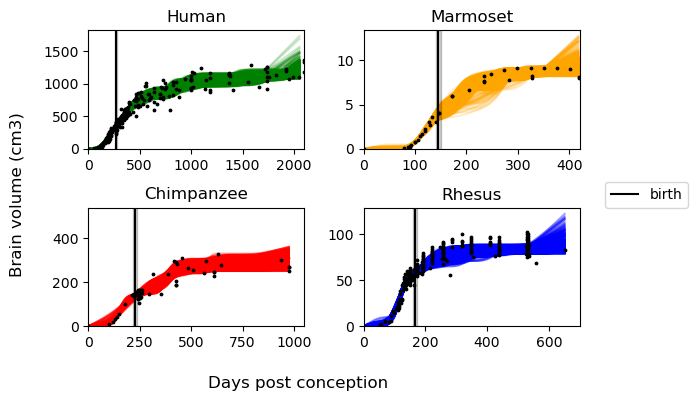

In [117]:
i = 0
fig, ax = plt.subplots(figsize = (6,4),nrows=2, ncols=2)

for row in ax:
    for col in row:
        species = species_list[i]
        df_species = df[(df.Species == species)]
        sensitivity_df_species = sensitivity_df[(sensitivity_df.Species == species)]
        col.set_title(species)
        x_values = x_each_species[species]
        for index, row in sensitivity_df_species.iterrows():
            col.plot(x_values, row["values"], '-', color = species_color[species],alpha = 0.2,zorder = 0)
        col.scatter(df_species[FIT_VARIABLE],df_species["total_cm3"],color = "black", marker = 'o', s =3)

        col.axvline(x = gestation_periods_plot[species], color = "black",linestyle = '-',label="birth" if i == 0 else "")
        col.axvspan(gestation_periods[species] - gestation_periods_sd[species], gestation_periods[species] + gestation_periods_sd[species], alpha=0.2, color='black')

        col.set_xlim(0,cut_period[species]*7)
        col.set_ylim(bottom=0)
        i += 1


fig.supxlabel('Days post conception') 
fig.supylabel('Brain volume (cm3)')
fig.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
fig.savefig("{0}/figs/SuppM_growth_fits_no_filtering_all.pdf".format(PYTHON_PATH),dpi = 300)
plt.show()

Human
Marmoset
Chimpanzee
Rhesus


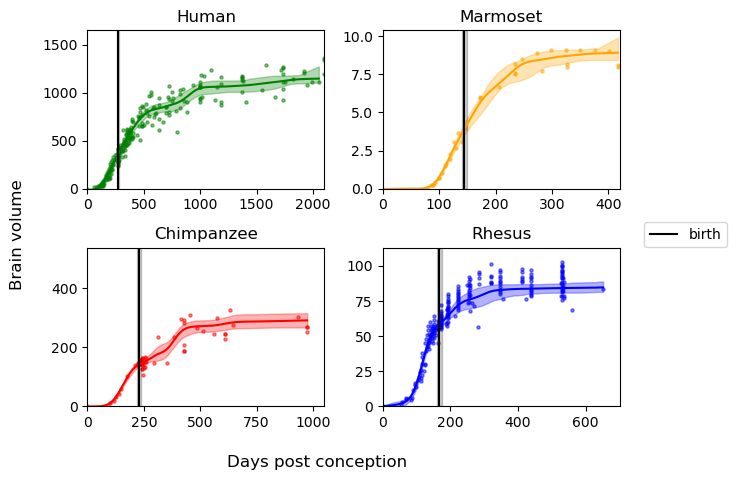

In [118]:
i = 0
fig, ax = plt.subplots(nrows=2, ncols=2)

for row in ax:
    for col in row:
        species = species_list[i]
        print(species)
        df_species = df[(df.Species == species)]
        sensitivity_df_species = sensitivity_df[(sensitivity_df.Species == species)]
        col.scatter(df_species[FIT_VARIABLE],df_species["total_cm3"],color = species_color[species], marker = 'o', s =5,alpha =0.5)
        col.set_title(species)
        
        all_curves = sensitivity_df_species["values"].tolist()
        average_curve = np.mean(np.array(all_curves), axis=0)
        low_95Percentil = gaussian_filter1d(np.percentile(np.array(all_curves),q = 2.5, axis=0), sigma = 1)
        max_95Percentil = gaussian_filter1d(np.percentile(np.array(all_curves),q = 97.5, axis=0), sigma = 1)


        col.plot(x_each_species[species], average_curve, '-', color = species_color[species],alpha = 1)
        col.fill_between(x_each_species[species], low_95Percentil,max_95Percentil, color=species_color[species], alpha=0.3)

        col.axvline(x = gestation_periods_plot[species], color = "black",linestyle = '-',label="birth" if i == 0 else "")
        col.axvspan(gestation_periods[species] - gestation_periods_sd[species], gestation_periods[species] + gestation_periods_sd[species], alpha=0.2, color='black')

        col.set_xlim(0,cut_period[species]*7)
        col.set_ylim(bottom=0)

        i += 1


fig.supxlabel('Days post conception') 
fig.supylabel('Brain volume')
fig.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.savefig("{0}/figs/SuppM_growth_fits_no_filtering_avg_95.pdf".format(PYTHON_PATH),dpi = 300)
plt.tight_layout()
plt.show()

### Calculate and plot derivatives

In [119]:
derivatives_dataset, sensitivity_df = create_derivatives_dataset(sensitivity_df,x_each_species,species_list,gestation_periods_plot,gestation_periods_sd)
derivatives_dataset.head()

,Species,derivatives,derivatives_wiggliness,derivatives_max,norm_y_distance_from_peak_at_birth,x_distance_from_peak_at_birth,percent_growth_at_birth,growth_curve_r2_score,growth_curve_wiggliness
0,Human,"[[2.9767968612759432e-05, 0.000119071969947981...","[1.792018220830948e-05, 2.045243363653202e-05,...","[2.3727882073224578, 2.2845172480382416, 2.214...","[[0.05838586626080628, 0.060304926367980974, 0...","[[41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48...","[[26.930882391599585, 27.106353597344494, 27.2...","[0.9546381439400614, 0.9547759885514042, 0.954...","[0.057607255661613344, 0.058805213167335696, 0..."
1,Marmoset,"[[-1.4290790772975015e-12, -1.460609411196856e...","[5.608648131442346e-06, 4.7616770625774635e-06...","[0.09333305573263972, 0.09437792024001457, 0.0...","[[0.4013045656416458, 0.38096579936273095, 0.3...","[[-19.0, -18.0, -17.0, -16.0, -15.0, -14.0, -1...","[[46.080443310489045, 46.861739431138986, 47.6...","[0.9897180842697205, 0.9894031339480914, 0.989...","[0.0005559978266892612, 0.0005293483174737889,..."
2,Chimpanzee,"[[-3.0951241569709964e-11, -3.126388037344441e...","[0.00016511859844551305, 0.0002054458837032695...","[1.4264698483958256, 1.5129754755298421, 1.589...","[[0.6250341726035926, 0.6338366243339915, 0.64...","[[72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79...","[[36.69696734086779, 36.841816558023844, 36.98...","[0.9189846520251368, 0.9210857097181354, 0.919...","[0.0953484996503573, 0.10592098584638064, 0.09..."
3,Rhesus,"[[0.009742121624014999, 0.00997707681254667, 0...","[7.632867731969286e-05, 0.00022998773636500133...","[0.788644378561397, 0.9962341198935292, 0.8954...","[[0.6483139375850314, 0.6670751785355366, 0.68...","[[44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51...","[[59.43731852883085, 59.71249766469418, 59.973...","[0.9303276081925919, 0.9359251421191207, 0.933...","[0.02320976296767592, 0.042084111911386855, 0...."


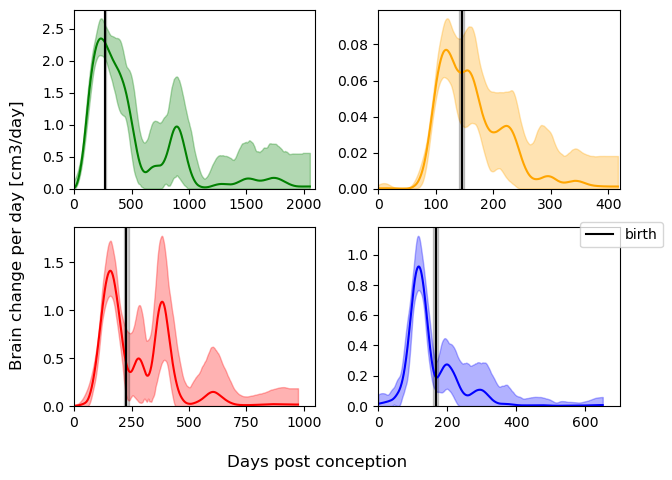

In [120]:
i = 0
fig, ax = plt.subplots(nrows=2, ncols=2)

for row in ax:
    for col in row:
        species= species_list[i]
        derivatives_dataset_species = derivatives_dataset[(derivatives_dataset.Species == species)]
        all_devs = derivatives_dataset_species["derivatives"].values[0]
        
        average_derivative = np.mean(np.array(all_devs), axis=0)
        low_95Percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 1)
        max_95Percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 1)

        col.fill_between(x_each_species[species], low_95Percentil,max_95Percentil, color=species_color[species], alpha=0.3)

        col.plot(x_each_species[species], average_derivative, '-', color = species_color[species],alpha = 1)
        col.axvline(x = gestation_periods_plot[species], color = "black",linestyle = '-',label="birth" if i == 0 else "")
        col.axvspan(gestation_periods[species] - gestation_periods_sd[species], gestation_periods[species] + gestation_periods_sd[species], alpha=0.2, color='black')
        col.set_ylim(bottom=0)
        col.set_xlim(0,cut_period[species]*7)

        i += 1

fig.supxlabel('Days post conception') 
fig.supylabel('Brain change per day [cm3/day]')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))
fig.savefig("{0}/figs/SuppM_derivatives_no_filtering_avg_95.pdf".format(PYTHON_PATH),dpi = 300)
fig.tight_layout()
plt.show()

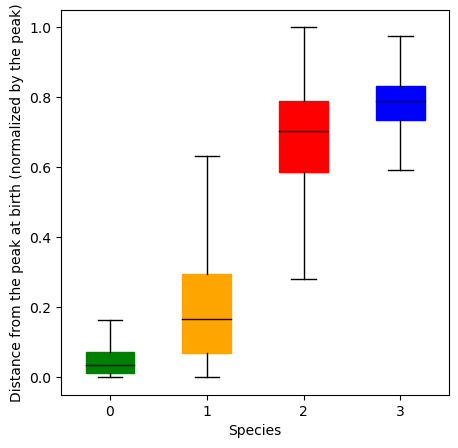

In [121]:
fig, ax = plt.subplots(figsize = (5,5))
for species in species_list:
    derivatives_dataset_species = derivatives_dataset[(derivatives_dataset.Species == species)]
    all_distances_from_the_peak = []
    for each_derivative in derivatives_dataset_species["norm_y_distance_from_peak_at_birth"].values[0]:
        all_distances_from_the_peak.extend(each_derivative)

    #plot as boxplots, each species in a different position in the x axis:
    ax.boxplot(x = all_distances_from_the_peak, positions= [species_list.index(species)], widths=0.5, showfliers=False,patch_artist=True, boxprops=dict(facecolor=species_color[species], color=species_color[species]), medianprops=dict(color="black"),whiskerprops=dict(color="black"))
ax.set_xlabel("Species")
ax.set_ylabel("Distance from the peak at birth (normalized by the peak)")
fig.savefig("{0}/figs/SuppM_boxplots_no_filter.pdf".format(PYTHON_PATH),dpi = 300)


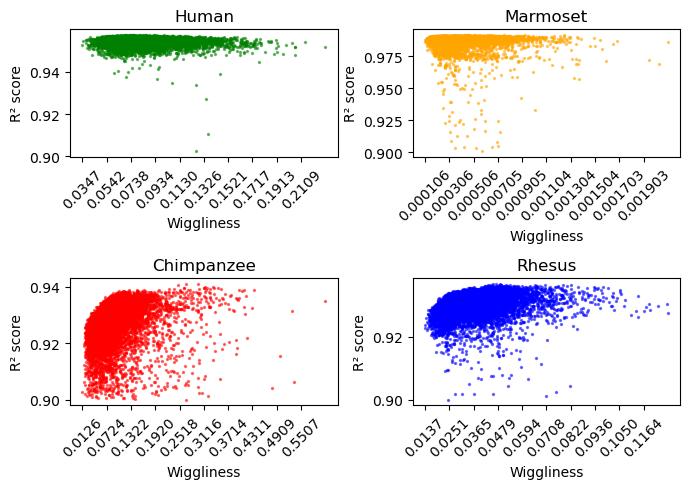

In [122]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(7,5))
i = 0
for row in ax:
    for col in row:
        species = species_list[i]
        sensitivity_df_species = sensitivity_df[sensitivity_df["Species"] == species]

        col.scatter(sensitivity_df_species["wiggliness"],
                    sensitivity_df_species["r2_score"],
                    color=species_color[species],
                    s=2, alpha=0.5)
        col.set_title(species)
        col.set_xlabel("Wiggliness")
        
        x_min_value = np.min(sensitivity_df_species["wiggliness"])
        x_max_value = np.max(sensitivity_df_species["wiggliness"])

        col.set_xticks(np.arange(x_min_value,x_max_value,(x_max_value - x_min_value)/10))
        col.tick_params(axis='x', labelsize=10,rotation=45)
        col.set_ylabel("R² score")
        i += 1
plt.tight_layout()
plt.show()

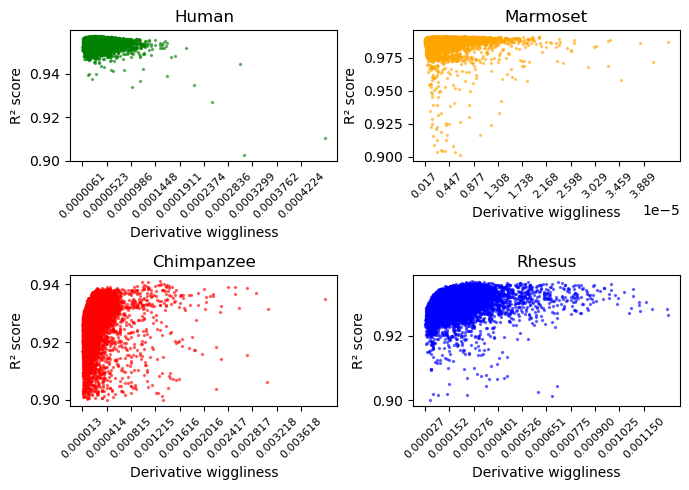

In [123]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(7,5))
i = 0
for row in ax:
    for col in row:
        species = species_list[i]
        sensitivity_df_species = sensitivity_df[sensitivity_df["Species"] == species]

        col.scatter(sensitivity_df_species["derivative_wiggliness"],
                    sensitivity_df_species["r2_score"],
                    color=species_color[species],
                    s=2, alpha=0.5)
        col.set_title(species)
        col.set_xlabel("Derivative wiggliness")
        
        x_min_value = np.min(sensitivity_df_species["derivative_wiggliness"])
        x_max_value = np.max(sensitivity_df_species["derivative_wiggliness"])

        col.set_xticks(np.arange(x_min_value,x_max_value,(x_max_value - x_min_value)/10))
        col.tick_params(axis='x', labelsize=8,rotation=45)
        col.set_ylabel("R² score")
        i += 1
plt.tight_layout()
plt.savefig("{0}/figs/SuppM_derivatives_r2_wiggliness.pdf".format(PYTHON_PATH),dpi = 300)
plt.show()

## Filter

In [124]:
sensitivity_df.head()

,Species,values,r2_score,wiggliness,spline_parameter,smooth_parameter,derivative_wiggliness,x_distance_from_peak
0,Human,"[-4.9764947931105326, -4.97646502514192, -4.97...",0.954638,0.057607,20,0.01,0.000018,50.0
1,Human,"[-9.747649362050765, -9.7476160849925, -9.7473...",0.954776,0.058805,22,0.01,0.00002,58.0
2,Human,"[-16.39162481362939, -16.39158462956459, -16.3...",0.954318,0.104318,25,0.01,0.000063,-26.0
3,Human,"[-10.297209756523444, -10.230583377589369, -10...",0.954480,0.050281,20,0.05,0.000014,45.0
4,Human,"[-8.560118086138573, -8.560085177504334, -8.55...",0.954655,0.055431,22,0.05,0.000018,56.0


In [125]:
#r2_species = {"Human": 0.95, "Chimpanzee":0.92, "Rhesus": 0.92, "Marmoset": 0.985}
#max_growth_wiggliness_species = {"Human": 1*10**(-1), "Chimpanzee":1*10**(-2), "Rhesus": 1*10**(-2), "Marmoset":1*10**(-4)}
max_derivative_wiggliness_species = {"Human": 1*10**(-4), "Chimpanzee": 1*10**(-4), "Rhesus": 1*10**(-4), "Marmoset": 1*10**(-6)}

sensitivity_df_filterd = pd.DataFrame()
for species in species_list:
    sensitivity_df_species = sensitivity_df[(sensitivity_df.Species == species)
                                        #& (sensitivity_df.r2_score > r2_species[species])
                                        #& (sensitivity_df.wiggliness < max_growth_wiggliness_species[species])
                                        & (sensitivity_df.x_distance_from_peak > 0)
                                        & (sensitivity_df.derivative_wiggliness < max_derivative_wiggliness_species[species])
                                        ]
    sensitivity_df_filterd = pd.concat([sensitivity_df_filterd,sensitivity_df_species])
    
derivatives_dataset_filtered, sensitivity_df_filterd = create_derivatives_dataset(sensitivity_df_filterd,x_each_species,species_list,gestation_periods_plot,gestation_periods_sd)
derivatives_dataset_filtered.head()


,Species,derivatives,derivatives_wiggliness,derivatives_max,norm_y_distance_from_peak_at_birth,x_distance_from_peak_at_birth,percent_growth_at_birth,growth_curve_r2_score,growth_curve_wiggliness
0,Human,"[[2.9767968612759432e-05, 0.000119071969947981...","[1.792018220830948e-05, 2.045243363653202e-05,...","[2.3727882073224578, 2.2845172480382416, 2.330...","[[0.05838586626080628, 0.060304926367980974, 0...","[[41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48...","[[26.930882391599585, 27.106353597344494, 27.2...","[0.9546381439400614, 0.9547759885514042, 0.954...","[0.057607255661613344, 0.058805213167335696, 0..."
1,Marmoset,"[[-2.2239987629291136e-12, -2.275957200481571e...","[9.26652043101264e-07, 6.851800155341962e-07, ...","[0.08040404281801461, 0.0779368340649027, 0.08...","[[0.20686947003891762, 0.22034040250365514, 0....","[[23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30...","[[52.02849344992026, 52.89881518683504, 53.754...","[0.988922017628168, 0.9890135776126797, 0.9890...","[0.00021308455814117677, 0.0001839879839112928..."
2,Chimpanzee,"[[1.746744484876217e-05, 6.9869835215286e-05, ...","[4.365428995656841e-05, 8.210554877602099e-05,...","[1.128083750420302, 1.2751718080320344, 1.3197...","[[0.40711007035816765, 0.41881658772849045, 0....","[[63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70...","[[36.01022184666351, 36.19170401506599, 36.369...","[0.9168320648229392, 0.9194372534554515, 0.927...","[0.04467777547886597, 0.059842384271511846, 0...."
3,Rhesus,"[[0.009742121624014999, 0.00997707681254667, 0...","[7.632867731969286e-05, 5.766777863805722e-05,...","[0.788644378561397, 0.7799614374531263, 0.7628...","[[0.6483139375850314, 0.6670751785355366, 0.68...","[[44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51...","[[59.43731852883085, 59.71249766469418, 59.973...","[0.9303276081925919, 0.9295443427231961, 0.928...","[0.02320976296767592, 0.020380040184627555, 0...."


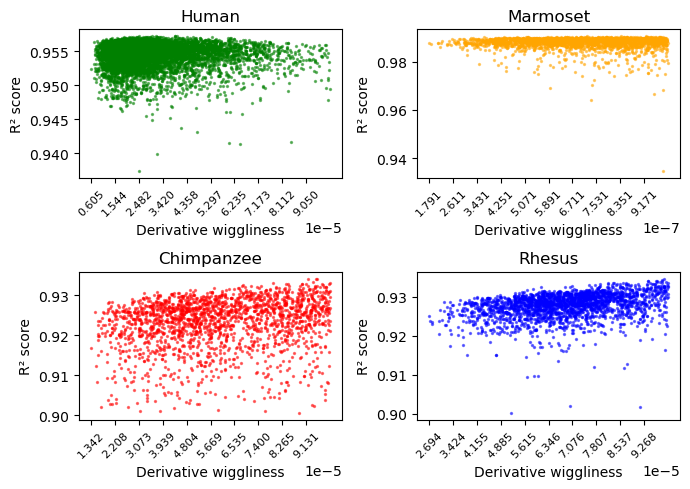

In [126]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(7,5))
i = 0
for row in ax:
    for col in row:
        species = species_list[i]
        sensitivity_df_species = sensitivity_df_filterd[sensitivity_df_filterd["Species"] == species]

        col.scatter(sensitivity_df_species["derivative_wiggliness"],
                    sensitivity_df_species["r2_score"],
                    color=species_color[species],
                    s=2, alpha=0.5)
        col.set_title(species)
        col.set_xlabel("Derivative wiggliness")
        
        x_min_value = np.min(sensitivity_df_species["derivative_wiggliness"])
        x_max_value = np.max(sensitivity_df_species["derivative_wiggliness"])

        col.set_xticks(np.arange(x_min_value,x_max_value,(x_max_value - x_min_value)/10))
        col.tick_params(axis='x', labelsize=8,rotation=45)
        col.set_ylabel("R² score")
        i += 1
plt.tight_layout()
plt.show()

Human
Marmoset
Chimpanzee
Rhesus


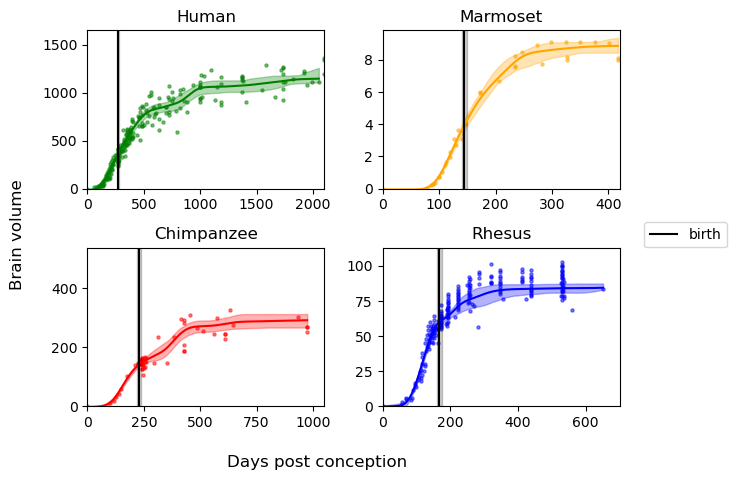

In [127]:
i = 0
fig, ax = plt.subplots(nrows=2, ncols=2)

for row in ax:
    for col in row:
        species = species_list[i]
        print(species)
        df_species = df[(df.Species == species)]
        sensitivity_df_species = sensitivity_df_filterd[(sensitivity_df_filterd.Species == species)]
        col.scatter(df_species[FIT_VARIABLE],df_species["total_cm3"],color = species_color[species], marker = 'o', s =5,alpha =0.5)
        col.set_title(species)
        
        all_curves = sensitivity_df_species["values"].tolist()
        average_curve = np.mean(np.array(all_curves), axis=0)
        low_95Percentil = gaussian_filter1d(np.percentile(np.array(all_curves),q = 2.5, axis=0), sigma = 1)
        max_95Percentil = gaussian_filter1d(np.percentile(np.array(all_curves),q = 97.5, axis=0), sigma = 1)



        col.plot(x_each_species[species], average_curve, '-', color = species_color[species],alpha = 1)
        col.fill_between(x_each_species[species], low_95Percentil,max_95Percentil, color=species_color[species], alpha=0.3)

        col.axvline(x = gestation_periods_plot[species], color = "black",linestyle = '-',label="birth" if i == 0 else "")
        col.axvspan(gestation_periods[species] - gestation_periods_sd[species], gestation_periods[species] + gestation_periods_sd[species], alpha=0.2, color='black')

        col.set_xlim(0,cut_period[species]*7)
        col.set_ylim(bottom=0)

        i += 1


fig.supxlabel('Days post conception') 
fig.supylabel('Brain volume')
fig.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
fig.savefig("{0}/figs/SuppM_growth_fits_avg_95.pdf".format(PYTHON_PATH),dpi = 300)
plt.show()

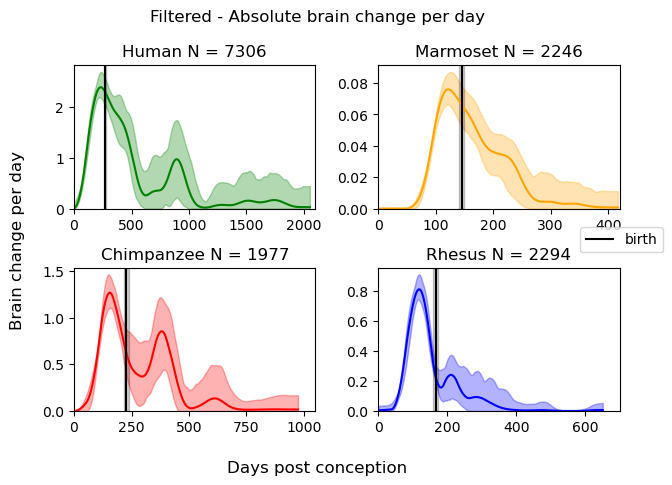

In [128]:
i = 0
fig, ax = plt.subplots(nrows=2, ncols=2)

for row in ax:
    for col in row:
        species= species_list[i]
        derivatives_dataset_species = derivatives_dataset_filtered[(derivatives_dataset_filtered.Species == species)]
        all_devs = derivatives_dataset_species["derivatives"].values[0]
        
        average_derivative = np.mean(np.array(all_devs), axis=0)
        low_95Percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 1)
        max_95Percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 1)

        col.fill_between(x_each_species[species], low_95Percentil,max_95Percentil, color=species_color[species], alpha=0.3)
        col.plot(x_each_species[species], average_derivative, '-', color = species_color[species],alpha = 1)

        col.axvline(x = gestation_periods_plot[species], color = "black",linestyle = '-',label="birth" if i == 0 else "")
        col.axvspan(gestation_periods[species] - gestation_periods_sd[species], gestation_periods[species] + gestation_periods_sd[species], alpha=0.2, color='black')
        col.set_ylim(bottom=0)
        col.set_xlim(0,cut_period[species]*7)
        col.set_title(species + f" N = {len(all_devs)}")

        i += 1
        
fig.suptitle("Filtered - Absolute brain change per day")
fig.supxlabel('Days post conception') 
fig.supylabel('Brain change per day')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))
fig.tight_layout()
fig.savefig("{0}/figs/SuppM_derivatives_avg_95.pdf".format(PYTHON_PATH),dpi = 300)
plt.show()

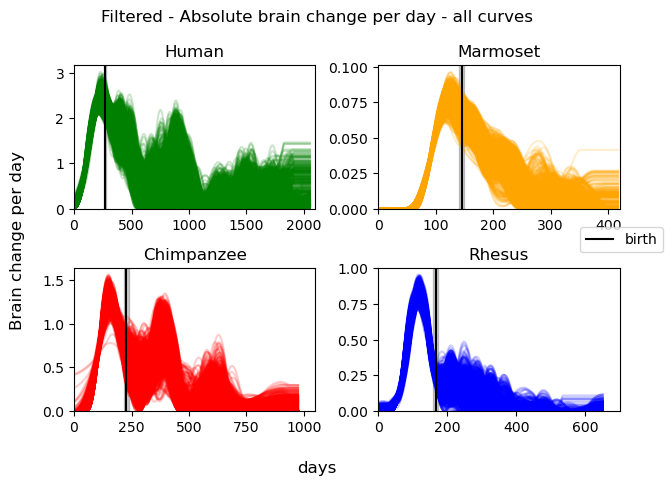

In [129]:
i = 0
derivative_data_species = {}
average_derivative = []
fig, ax = plt.subplots(nrows=2, ncols=2)

for row in ax:
    for col in row:
        species= species_list[i]
        derivatives_dataset_species = derivatives_dataset_filtered[(derivatives_dataset_filtered.Species == species)]
        all_devs = derivatives_dataset_species["derivatives"].values[0]

        for dev in all_devs:
            dev = np.array(dev)
            col.plot(x_each_species[species], dev, '-', color = species_color[species],alpha = 0.2)

        col.axvline(x = gestation_periods_plot[species], color = "black",linestyle = '-',label="birth" if i == 0 else "")
        col.axvspan(gestation_periods[species] - gestation_periods_sd[species], gestation_periods[species] + gestation_periods_sd[species], alpha=0.2, color='black')
        col.set_ylim(bottom=0)
        col.set_xlim(0,cut_period[species]*7)
        col.set_title(species)

        i += 1

fig.suptitle("Filtered - Absolute brain change per day - all curves")
fig.supxlabel('days') 
fig.supylabel('Brain change per day')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))
fig.tight_layout()
plt.show()

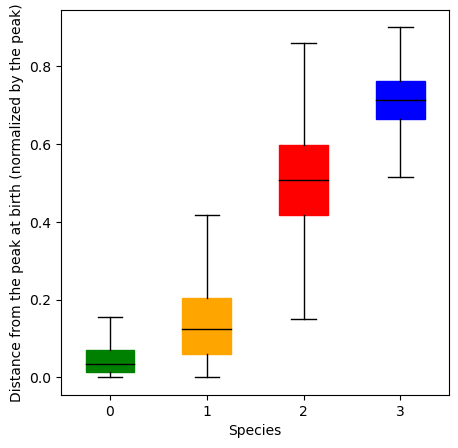

In [130]:
fig, ax = plt.subplots(figsize = (5,5))
for species in species_list:
    derivatives_dataset_species = derivatives_dataset_filtered[(derivatives_dataset_filtered.Species == species)]
    all_distances_from_the_peak = []
    for each_derivative in derivatives_dataset_species["norm_y_distance_from_peak_at_birth"].values[0]:
        all_distances_from_the_peak.extend(each_derivative)

    #plot as boxplots, each species in a different position in the x axis:
    ax.boxplot(x = all_distances_from_the_peak, positions= [species_list.index(species)], widths=0.5, showfliers=False,patch_artist=True, boxprops=dict(facecolor=species_color[species], color=species_color[species]), medianprops=dict(color="black"),whiskerprops=dict(color="black"))
ax.set_xlabel("Species")
ax.set_ylabel("Distance from the peak at birth (normalized by the peak)")
fig.savefig("{0}/figs/SuppM_boxplots.pdf".format(PYTHON_PATH),dpi = 300)


Text(0, 0.5, 'Distance from the peak at birth (days)')

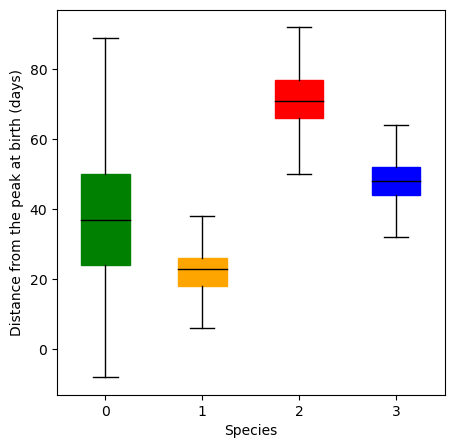

In [131]:
fig, ax = plt.subplots(figsize = (5,5))
for species in species_list:
    derivatives_dataset_species = derivatives_dataset_filtered[(derivatives_dataset_filtered.Species == species)]
    all_distances_from_the_peak = []
    for each_distance in derivatives_dataset_species["x_distance_from_peak_at_birth"].values[0]:
        all_distances_from_the_peak.extend(each_distance)

    #plot as boxplots, each species in a different position in the x axis:
    ax.boxplot(x = all_distances_from_the_peak, positions= [species_list.index(species)], widths=0.5, showfliers=False,patch_artist=True, boxprops=dict(facecolor=species_color[species], color=species_color[species]), medianprops=dict(color="black"),whiskerprops=dict(color="black"))
ax.set_xlabel("Species")
ax.set_ylabel("Distance from the peak at birth (days)")



Human 27.97925979065165
Marmoset 54.42543281428583
Chimpanzee 38.24599698939535
Rhesus 60.688849382832416


Text(0, 0.5, '% growth at birth (normalized by the adult brain volume)')

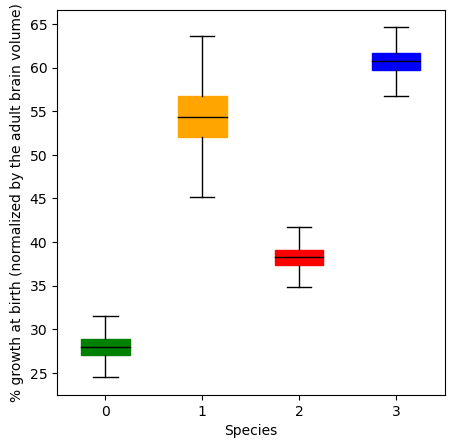

In [132]:
fig, ax = plt.subplots(figsize = (5,5))
for species in species_list:
    derivatives_dataset_species = derivatives_dataset_filtered[(derivatives_dataset_filtered.Species == species)]
    all_distances_from_the_peak = []
    for each_distance in derivatives_dataset_species["percent_growth_at_birth"].values[0]:
        all_distances_from_the_peak.extend(each_distance)

    print(species, np.mean(all_distances_from_the_peak))
    #plot as boxplots, each species in a different position in the x axis:
    ax.boxplot(x = all_distances_from_the_peak, positions= [species_list.index(species)], widths=0.5, showfliers=False,patch_artist=True, boxprops=dict(facecolor=species_color[species], color=species_color[species]), medianprops=dict(color="black"),whiskerprops=dict(color="black"))
ax.set_xlabel("Species")
ax.set_ylabel("% growth at birth (normalized by the adult brain volume)")

In [133]:
df_save = {"species":[],"x_dydx":[],"derivatives":[],"derivatives_max":[],"norm_y_distance_from_peak_at_birth":[],"x_distance_from_peak_at_birth":[]}    

for species in species_list:

    df_save["species"].append(species)
    df_save["x_dydx"].append(x_each_species[species])
    df_save["derivatives"].append(derivatives_dataset_filtered[(derivatives_dataset_filtered.Species == species)]["derivatives"].item())
    df_save["derivatives_max"].append(derivatives_dataset_filtered[(derivatives_dataset_filtered.Species == species)]["derivatives_max"].item())
    df_save["norm_y_distance_from_peak_at_birth"].append(derivatives_dataset_filtered[(derivatives_dataset_filtered.Species == species)]["norm_y_distance_from_peak_at_birth"].item())
    df_save["x_distance_from_peak_at_birth"].append(derivatives_dataset_filtered[(derivatives_dataset_filtered.Species == species)]["x_distance_from_peak_at_birth"].item())


df_save = pd.DataFrame(df_save)
df_save.to_pickle("{0}/data/derivatives_absolute_values.pkl".format(PYTHON_PATH)) 
